# Visualizing the 76.53% EDSR Model
This notebook loads the `checkpoints/edsr_epoch_50.pth` weights and runs a single degraded image through the network so you can visually inspect what 76% Structural Similarity looks like to the human eye.


Loading on: cuda
Weights loaded successfully.


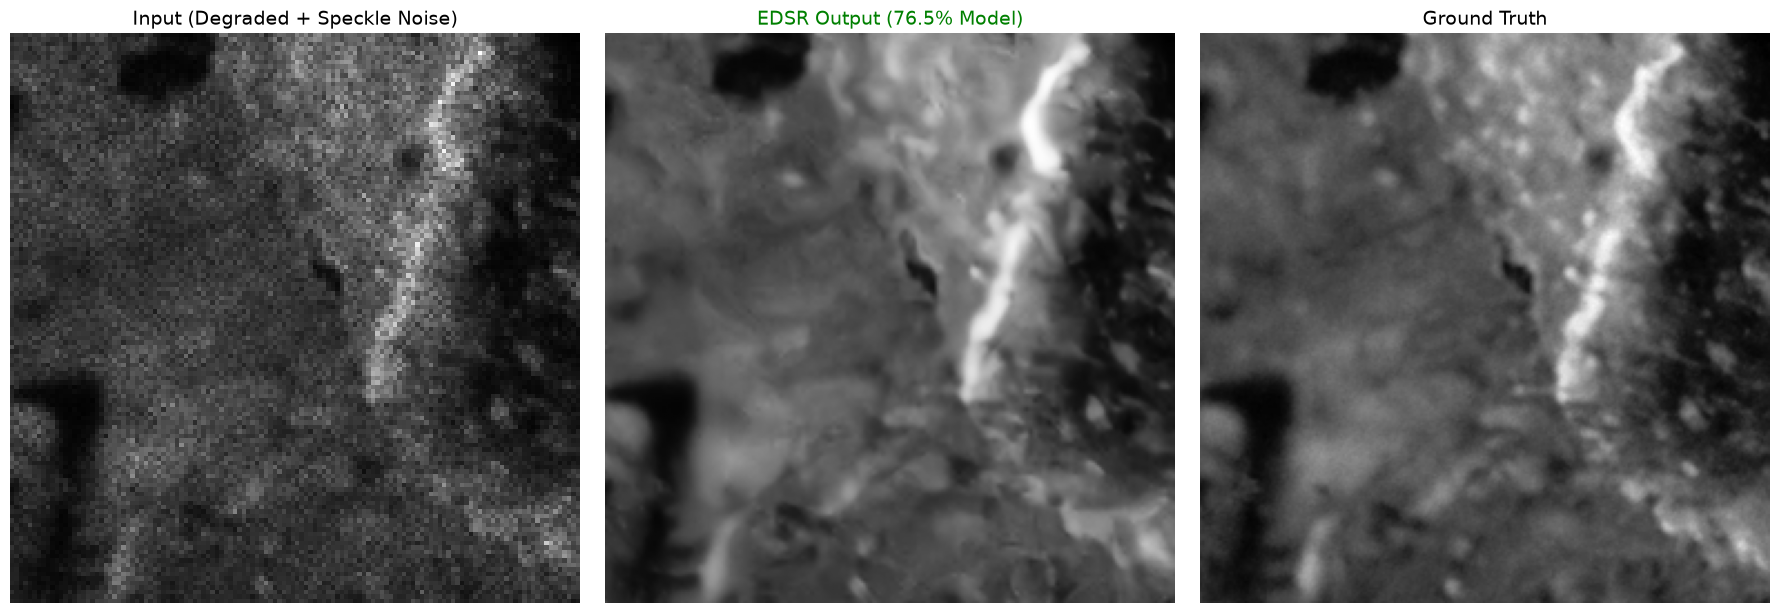

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from src.config import Config
from src.model.edsr import MultiTaskEDSR

# 1. Load the Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Loading on: {device}")

model = MultiTaskEDSR(
    scale=Config.SCALE,
    num_filters=Config.NUM_FILTERS,
    num_res_blocks=Config.NUM_RES_BLOCKS,
    channels=Config.CHANNELS
).to(device)

# Load the proven 76.53% checkpoint
model.load_state_dict(torch.load("checkpoints/edsr_epoch_50.pth", map_location=device, weights_only=True))
model.eval()
print("Weights loaded successfully.")

# 2. Pick an image
noisy_files = sorted(glob.glob(os.path.join(Config.TRAIN_NOISY_DIR, '*.npy')))
gt_files = sorted(glob.glob(os.path.join(Config.TRAIN_GT_DIR, '*.npy')))

idx = 1  # Feel free to change this index to test different images!
noisy_img = np.load(noisy_files[idx])
gt_img = np.load(gt_files[idx])

# 3. Format tensor for the network: Shape (Batch, Channel, Height, Width)
input_tensor = torch.from_numpy(noisy_img).unsqueeze(0).unsqueeze(0).float().to(device)

# 4. Run the forward pass!
with torch.no_grad():
    output_tensor = model(input_tensor)

# 5. Convert back to numpy for matplotlib
output_img = output_tensor.squeeze().cpu().numpy()
# COMPRESS the values strictly into 0-1 without losing data (Min-Max Scaling)
output_img = (output_img - output_img.min()) / (output_img.max() - output_img.min() + 1e-8)
noisy_img = (noisy_img - noisy_img.min()) / (noisy_img.max() - noisy_img.min() + 1e-8)
gt_img = (gt_img - gt_img.min()) / (gt_img.max() - gt_img.min() + 1e-8)

# 6. Plot the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(noisy_img, cmap='gray')
axes[0].set_title("Input (Degraded + Speckle Noise)", fontsize=14)
axes[0].axis('off')

axes[1].imshow(output_img, cmap='gray')
axes[1].set_title("EDSR Output (76.5% Model)", fontsize=14, color='green')
axes[1].axis('off')

axes[2].imshow(gt_img, cmap='gray')
axes[2].set_title("Ground Truth", fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()
